In [3]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
%matplotlib notebook

In [246]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Figures\Posters\SAC_2026'

In [189]:
target_mice = [803121]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 6 session assets


In [190]:
asset = assets[3]
print(asset.session_id)
gs = GlutamateSummary(asset.summary_mat)

803121_2025-11-01_19-00-21


### Plot raw data from a single segment of a session for one synapse

In [191]:
epoch_path = os.path.join(asset.qc_dir,'behavior','imaging_epochs.csv')
image_epochs = pd.read_csv(epoch_path)
start_time = image_epochs['start_time']
end_time = image_epochs['end_time']

In [192]:
stim_path = os.path.join(asset.qc_dir,'glutamate','glutamate_extraction_qc.json')

with open(stim_path, "r") as f:
    im_json = json.load(f)

In [193]:
im_colors = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8',
    '#9fd3f2']

<IPython.core.display.Javascript object>


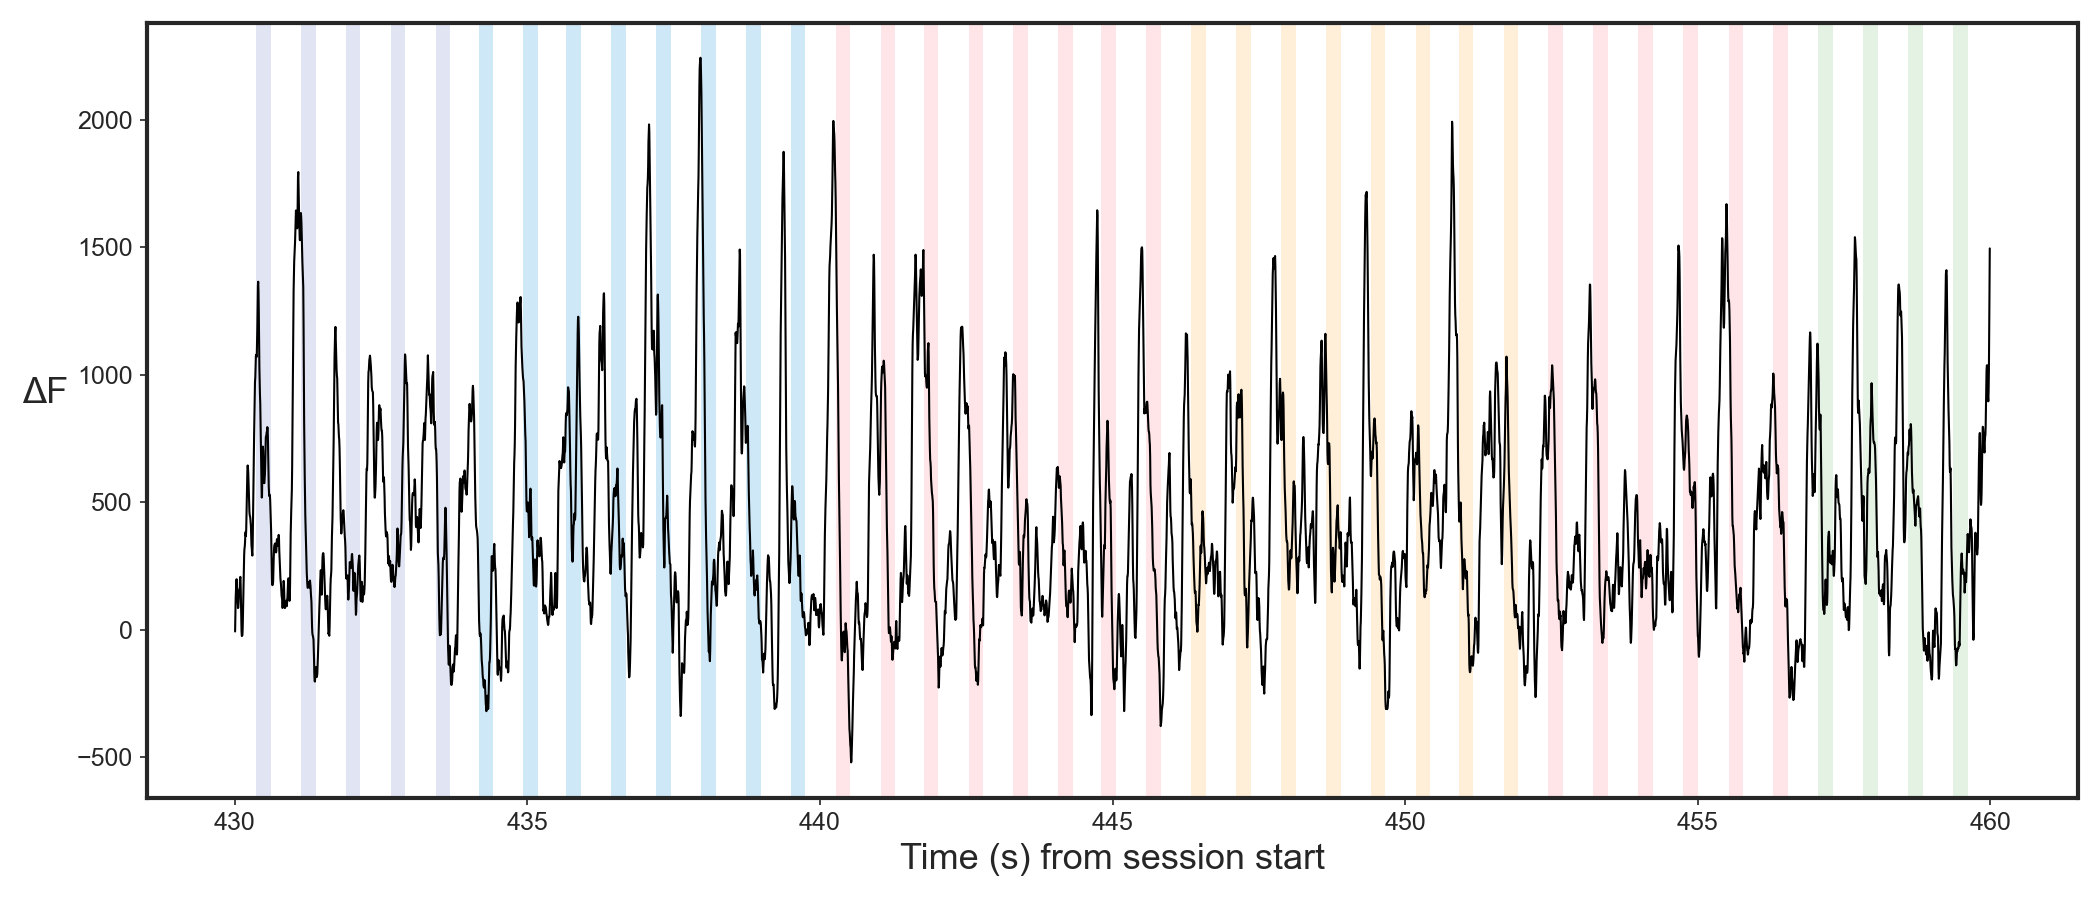

Effective sample rate: 200.002 Hz
Expected duration: 1740.008 s
Trace duration at 200 Hz: 1740.030 s


In [195]:
dmd = 2
synapse = 77

valid_trials = gs.valid_trials[dmd-1]
total_trials = gs.n_trials

traces = []

for trial in range(total_trials):
    if trial in valid_trials:
        trace = gs.get_traces(dmd=dmd,trial=trial)[:,synapse]
    else:
        shape = np.shape(gs.get_traces(dmd=dmd,trial=valid_trials[0])[:,synapse])
        trace = np.full(shape,np.nan)
    traces.append(trace)
    
traces = np.concatenate(traces)[:]

fig,ax=plt.subplots(figsize=(14,6))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

epoch = image_epochs.iloc[0]

t0 = float(epoch["start_time"])
t1 = float(epoch["end_time"])

fs_eff = (len(traces) - 1) / (t1 - t0)
print(f"Effective sample rate: {fs_eff:.3f} Hz")
print(f"Expected duration: {t1 - t0:.3f} s")
print(f"Trace duration at 200 Hz: {len(traces) / 200:.3f} s")

time = t0 + np.arange(len(traces)) / fs_eff

time_window = (430,460)

start,stop = np.where(time>=time_window[0])[0][0],np.where(time<=time_window[1])[0][-1]

rolling = (
    pd.Series(traces)
    .rolling(20, center=True, min_periods=1)
    .mean()
    .to_numpy()
)

ax.plot(time[start:stop], rolling[start:stop], color="k", lw=1)

# stimulus onsets from your qc json
image_onsets = im_json["per_dmd"][f"DMD{dmd}"]["stimulus_onsets_used_for_extraction"]["image_identity"]

# map image ids to your existing colors
image_ids = list(image_onsets.keys())
image_color_map = dict(zip(image_ids, im_colors[:len(image_ids)]))

win0, win1 = time_window

for image_id, onset_list in image_onsets.items():
    color = image_color_map[image_id]
    
    for onset in np.unique(np.asarray(onset_list, dtype=float)):
        span_start = onset
        span_end = onset + 0.25

        # only draw spans that overlap the plotted window
        if span_end >= win0 and span_start <= win1:
            ax.axvspan(
                max(span_start, win0),
                min(span_end, win1),
                color=color,
                alpha=0.5,
                lw=0,
                zorder=-1,
            )


ax.set_xlabel('Time (s) from session start')
ax.set_ylabel('\u0394F',rotation=0,labelpad=15)

for spine in ['top','bottom','left','right']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

filen = 'example_untuned_trace'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi=300)

Effective sample rate: 200.002 Hz
Expected duration: 1740.008 s
Trace duration at 200 Hz: 1740.030 s


<IPython.core.display.Javascript object>


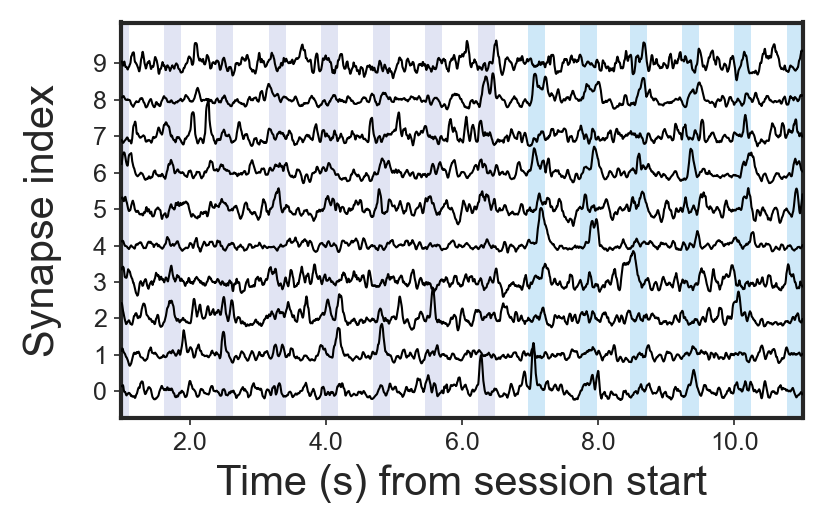

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_40392\2522201779.py:167: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.linspace(0,max(xticks)-min(xticks),len(xticks)))


In [247]:
dmd = 2
synapses = [71,72,73,74,75,76, 77, 78, 79, 80]  # arbitrary number of synapses from this DMD

time_window = (431, 441)
smooth_window = 10
onset_shift_s = +2.8  # use 0.0 for unshifted stimulus spans

stack_spacing = 1.5
trace_height = 1.25# vertical size of each trace in row units
show_raw = False


# -------------------------
# Build continuous traces
# -------------------------

valid_trials = set(gs.valid_trials[dmd - 1])
total_trials = gs.n_trials

trial_traces = []

# Use first valid trial to infer shape
example = gs.get_traces(dmd=dmd, trial=sorted(valid_trials)[0])[:, synapses]
example_shape = example.shape

for trial in range(total_trials):
    if trial in valid_trials:
        trace = gs.get_traces(dmd=dmd, trial=trial)[:, synapses]
    else:
        trace = np.full(example_shape, np.nan)

    trial_traces.append(trace)

traces = np.concatenate(trial_traces, axis=0)

if traces.ndim == 1:
    traces = traces[:, None]


# -------------------------
# Build explicit time axis
# -------------------------

epoch = image_epochs.iloc[0]

t0 = float(epoch["start_time"])
t1 = float(epoch["end_time"])

fs_eff = (len(traces) - 1) / (t1 - t0)

print(f"Effective sample rate: {fs_eff:.3f} Hz")
print(f"Expected duration: {t1 - t0:.3f} s")
print(f"Trace duration at 200 Hz: {len(traces) / 200:.3f} s")

time = t0 + np.arange(len(traces)) / fs_eff

start = np.searchsorted(time, time_window[0], side="left")
stop = np.searchsorted(time, time_window[1], side="right")


# -------------------------
# Smooth traces
# -------------------------

smooth = np.column_stack([
    pd.Series(traces[:, i])
    .rolling(smooth_window, center=True, min_periods=1)
    .mean()
    .to_numpy()
    for i in range(traces.shape[1])
])


# -------------------------
# Plot
# -------------------------

fig, ax = plt.subplots(figsize=(5.5, 3.5))

ax.tick_params(axis="x", which="major", reset=True, top=False, labelsize=12)
ax.tick_params(axis="y", which="major", reset=True, right=False, labelsize=12)

n_syn = len(synapses)
y_offsets = np.arange(n_syn) * stack_spacing

for i, synapse in enumerate(synapses):
    y0 = y_offsets[i]

    tr = smooth[:, i]

    # Center each trace and robust-scale it for stacked visualization
    tr_centered = tr - np.nanmedian(tr[start:stop])

    q_low, q_high = np.nanpercentile(tr_centered[start:stop], [1, 99])
    robust_range = q_high - q_low

    if not np.isfinite(robust_range) or robust_range == 0:
        robust_range = np.nanstd(tr_centered[start:stop])

    if not np.isfinite(robust_range) or robust_range == 0:
        robust_range = 1.0

    tr_vis = y0 + trace_height * (tr_centered / robust_range)

    if show_raw:
        raw_centered = traces[:, i] - np.nanmedian(traces[start:stop, i])
        raw_vis = y0 + trace_height * (raw_centered / robust_range)

        ax.plot(
            time[start:stop],
            raw_vis[start:stop],
            color="0.7",
            lw=0.5,
            alpha=0.4,
            zorder=2,
        )

    ax.plot(
        time[start:stop],
        tr_vis[start:stop],
        color="k",
        lw=1,
        zorder=3,
    )


# -------------------------
# Stimulus spans
# -------------------------

image_onsets = im_json["per_dmd"][f"DMD{dmd}"]["stimulus_onsets_used_for_extraction"]["image_identity"]

image_ids = list(image_onsets.keys())
image_color_map = dict(zip(image_ids, im_colors[:len(image_ids)]))

win0, win1 = time_window

for image_id, onset_list in image_onsets.items():
    color = image_color_map[image_id]

    for onset in np.unique(np.asarray(onset_list, dtype=float)):
        span_start = onset + onset_shift_s
        span_end = onset + 0.25 + onset_shift_s

        if span_end >= win0 and span_start <= win1:
            ax.axvspan(
                max(span_start, win0),
                min(span_end, win1),
                color=color,
                alpha=0.5,
                lw=0,
                zorder=0,
            )


# -------------------------
# Axes formatting
# -------------------------

ax.set_xlim(time_window)

ax.set_yticks(y_offsets)
ax.set_yticklabels([str(s-min(synapses)) for s in synapses])
ax.set_ylabel("Synapse index", fontsize=20,labelpad=15)

xticks = ax.get_xticks()
ax.set_xticklabels(np.linspace(0,max(xticks)-min(xticks),len(xticks)))

ax.set_xlabel("Time (s) from session start",fontsize=20)

# ax.set_ylim(
#     y_offsets[0] - stack_spacing,
#     y_offsets[-1] + stack_spacing,
# )

for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

filen = f"DMD{dmd}_stacked_synapse_traces"
save_figure(fig, os.path.join(savepath, filen), formats=[".pdf", ".png"], dpi=300)

### Plot mean image responses

In [185]:
gs_mean_path = glob.glob(os.path.join(asset.derived_dir,'glutamate','glutamate_mean_df.npz'))[0]
mean_data = np.load(gs_mean_path,allow_pickle=True)['data'][0][f'DMD{dmd}']['image_identity']

In [186]:
im_names = list(mean_data.keys())
im_names

['stimuli\\images_B\\100075.tiff',
 'stimuli\\images_B\\216066.tiff',
 'stimuli\\images_B\\268048.tiff',
 'stimuli\\images_B\\41006.tiff',
 'stimuli\\images_B\\McGill_stairs.tiff',
 'stimuli\\images_B\\imk01306.tiff',
 'stimuli\\images_B\\imk01333.tiff']

<IPython.core.display.Javascript object>


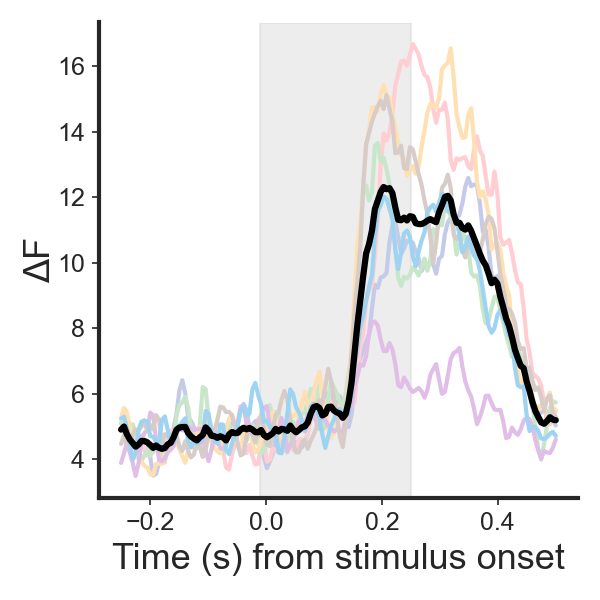

In [187]:
synapse = 13

fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

trial_shape = mean_data[im_names[0]]['mean'][synapse].shape[0]
time = np.linspace(-0.25,0.5,trial_shape)

for i,im in enumerate(im_names):
    syn_data = mean_data[im]['mean'][synapse]
    im_rolling = pd.DataFrame(syn_data).rolling(1,min_periods=1).mean()
    ax.plot(time,im_rolling,color=im_colors[i],lw=2)
    
mean = np.mean([mean_data[im]['mean'][synapse] for im in im_names],axis=0)
rolling_mean  = pd.DataFrame(mean).rolling(1,min_periods=1).mean()

ax.plot(time,mean,color='k',lw=3)
ax.axvspan(-0.01,0.25,color='lightgray',alpha=0.4,zorder=0)

ax.set_xlabel('Time (s) from stimulus onset')
ax.set_ylabel('\u0394F',rotation=90,labelpad=0)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

filen = f'synapse{synapse}_image responses'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

### Plot the response of a given synapse to a single trial

In [ ]:
gs_trial_path = glob.glob(os.path.join(asset.derived_dir,'glutamate','glutamate_single_trial_df.npz'))[0]

In [ ]:
trial_data = np.load(gs_trial_path,allow_pickle=True)['data'][0][f'DMD{dmd}']['image_identity']

In [ ]:
im_names = list(trial_data.keys())
im_names

In [ ]:
i = 4
synapse_trials = trial_data[im_names[i]][:,synapse,:]

trial_shape = synapse_trials.shape[1]

# tr= 250
fs = 200
for ii,tr in enumerate(np.arange(219,222)):
    fig,ax=plt.subplots(figsize=(4,4))

    sns.despine(left=True)
    
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    
    time = np.linspace(-0.25,0.5,trial_shape)

    rolling = pd.DataFrame(synapse_trials[tr]).rolling(5,min_periods=1).mean()

    ax.plot(time,rolling,color='k',lw=2)

    ax.set_yticks([])

    ax.set_xlabel('Time (s) from stim. onset')

    ax.spines['bottom'].set_linewidth(2)

    ax.axvspan(0.0,0.25,color=im_colors[i],alpha=0.5,zorder=0)
    ax.set_ylabel(f'Trial {ii+1}',rotation=0,labelpad=25)
    fig.tight_layout()
    filen = f'example_Trial{ii}'
    save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

In [ ]:
i = 4
synapse_trials = trial_data[im_names[i]][:,synapse,:]
trial_shape = synapse_trials.shape[1]

# tr= 250
fs = 200
fig,ax=plt.subplots(figsize=(4,4))

sns.despine(left=True)

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

time = np.linspace(-0.25,0.5,trial_shape)

mean = np.nanmean(synapse_trials,axis=0)

rolling = pd.DataFrame(mean).rolling(5,min_periods=1).mean()

ax.plot(time,rolling,color='k',lw=2)

ax.set_yticks([])

ax.set_xlabel('Time (s) from stim. onset')

ax.spines['bottom'].set_linewidth(2)

ax.axvspan(0.0,0.25,color=im_colors[i],alpha=0.5,zorder=0)
ax.set_ylabel(f'Trial {ii+1}',rotation=0,labelpad=25)
fig.tight_layout()
filen = f'example_mean'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

In [ ]:
i = 4
synapse_trials = trial_data[im_names[i]][:,synapse,:]
trial_shape = synapse_trials.shape[1]
fig,ax=plt.subplots(figsize=(4,4))
time = np.linspace(-0.25,0.5,trial_shape)
# tr= 250
fs = 200
for ii,tr in enumerate(synapse_trials):

    sns.despine(left=True)
    
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

    rolling = pd.DataFrame(synapse_trials[ii]).rolling(5,min_periods=1).mean()

    ax.plot(time,rolling,color=im_colors[i],lw=1,alpha=0.3)

mean = np.nanmean(synapse_trials,axis=0)
rolling_mean = pd.DataFrame(mean).rolling(5,min_periods=1).mean()

ax.plot(time,rolling_mean,color='k',lw=2)

ax.set_ylabel('\u0394F',rotation=0,labelpad=15)
ax.set_xlabel('Time (s) from stim. onset')

ax.axvline(0.0,color='k',dashes=[5,5])

# ax.set_ylim(0,500)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
    
fig.tight_layout()
filen = f'example_im{i}'
# save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf'],dpi=300)

### Plot dF/F for a given synapses' mean responses

In [ ]:
gs_dff_path = glob.glob(os.path.join(asset.derived_dir,'glutamate','glutamate_mean_dff_ls.npz'))[0]

In [ ]:
dff_data = np.load(gs_dff_path,allow_pickle=True)['data'][0][f'DMD{dmd}']['image_identity']

In [ ]:
im_names = list(dff_data.keys())
im_names

In [ ]:
synapse = 40

fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

trial_shape = dff_data[im_names[0]]['mean'][synapse].shape[0]
time = np.linspace(-0.25,0.5,trial_shape)

for i,im in enumerate(im_names):
    syn_data = dff_data[im]['mean'][synapse]
    im_rolling = pd.DataFrame(syn_data).rolling(1,min_periods=1).mean()
    ax.plot(time,im_rolling,color=im_colors[i],lw=2)
    
mean = np.mean([dff_data[im]['mean'][synapse] for im in im_names],axis=0)
rolling_mean  = pd.DataFrame(mean).rolling(1,min_periods=1).mean()

ax.plot(time,mean,color='k',lw=3)
ax.axvspan(-0.01,0.25,color='lightgray',alpha=0.4,zorder=0)

ax.set_xlabel('Time (s) from stimulus onset')
ax.set_ylabel('\u0394F/F$_{0}$',rotation=90,labelpad=0)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

In [ ]:
mean